# 03 消融测试 + 安慰剂测试 (Ablation & Placebo)

## 实验概述

**目的：** 通过逐步掩码不同信息维度，找出最大的记忆触发因素；通过安慰剂测试验证模型是否真正在分析文本。

**消融测试方法：** 逐步掩码年份→实体→数字→板块，观察每步掩码对泄露指标的影响。掩码后 L 下降最多的维度 = 最大的记忆触发因素。包含 rule-based 和 LLM-based 两种掩码模式的对比。

**实体掩码方式对比：** 三种处理方式——占位符 `[实体N]`（rule-based）、LLM 自然模糊化、虚构实体替换（entity swap）。PC 高 = 模型正确忽略实体名（好），PC 低 = 模型依赖实体名（可能是记忆触发）。

**安慰剂测试方法：** 用 LLM 生成自相矛盾的虚构新闻，使理性分析者无法得出确定方向。如果模型在安慰剂数据上准确率仍高，说明它在"回忆"而非"分析"。

**关键指标：**
- PC / CI / IDS / L：见 notebook 02 定义
- 安慰剂准确率阈值：majority_class_rate + 10% = 55%（数据集 up:19, down:17, neutral:6，多数类占比 45%）

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src import set_seed, DEFAULT_CONCURRENCY
from src.masking import extract_json_robust
from src.models import *
from src.llm_client import LLMClient
from src.news_loader import load_test_cases, load_counterfactual_variants
from src.experiment import run_counterfactual_attack, run_scoring_batch
from src.masking import apply_masking
from src.prompts import scoring_prompt, entity_swap_prompt, placebo_rewrite_prompt
from src.metrics import prediction_consistency, confidence_invariance, input_dependency_score, composite_leakage_score
from src.display_utils import show_comparison, strip_markdown_json
import json
import numpy as np
import pandas as pd
import random

set_seed()
(PROJECT_ROOT / "data" / "results").mkdir(parents=True, exist_ok=True)

## 1. 消融测试：逐维度掩码

In [2]:
test_cases = load_test_cases()
variants = load_counterfactual_variants()
variant_map = {}
for v in variants:
    variant_map.setdefault(v.original_case_id, {})[v.variant_type] = v

client = LLMClient()
output_format = "5-bin"

# Rule-based ablation: progressively add masks
ablation_configs = {
    "baseline": MaskingConfig(),
    "+year": MaskingConfig(mask_year=True),
    "+year+entity": MaskingConfig(mask_year=True, mask_entity=True),
    "+year+entity+number": MaskingConfig(mask_year=True, mask_entity=True, mask_numbers=True),
    "+year+entity+number+sector": MaskingConfig(mask_year=True, mask_entity=True, mask_numbers=True, mask_sector=True),
    "full (all+role+cot+constraint)": MaskingConfig(mask_year=True, mask_entity=True, mask_numbers=True, mask_sector=True, role_play=True, cot_forced=True, extraction_constraint=True),
}

# LLM-based ablation configs
llm_configs = {
    "llm_entity": MaskingConfig(mask_entity=True, mask_mode="llm"),
    "llm_full_mask": MaskingConfig(mask_year=True, mask_entity=True, mask_numbers=True, mask_sector=True, mask_mode="llm"),
    "llm_full+role+cot+constraint": MaskingConfig(
        mask_year=True, mask_entity=True, mask_numbers=True, mask_sector=True,
        mask_mode="llm", role_play=True, cot_forced=True, extraction_constraint=True,
    ),
}

# Combine all configs
all_configs = {**ablation_configs, **llm_configs}

In [3]:
def parse_5bin(raw: str) -> dict:
    data = extract_json_robust(raw)
    if not data:
        return {"direction": "neutral", "confidence": 0.5, "distribution": [0.2]*5}
    dist = [data.get(k, 20) for k in ["strong_bear", "weak_bear", "neutral", "weak_bull", "strong_bull"]]
    total = sum(dist)
    dist = [d/total for d in dist] if total > 0 else [0.2]*5
    bull, bear = dist[3]+dist[4], dist[0]+dist[1]
    direction = "up" if bull > bear + 0.1 else ("down" if bear > bull + 0.1 else "neutral")
    return {"direction": direction, "confidence": max(bull, bear, dist[2]), "distribution": dist}

ablation_results = []
for config_name, config in all_configs.items():
    print(f"\nRunning: {config_name}")

    orig_responses, cf_responses, task_meta = run_counterfactual_attack(
        client, config, test_cases, variant_map, output_format
    )

    for (tc, vt_name), orig_resp, cf_resp in zip(task_meta, orig_responses, cf_responses):
        orig = parse_5bin(orig_resp.raw_response)
        cf = parse_5bin(cf_resp.raw_response)
        ablation_results.append({
            "config": config_name, "case_id": tc.id, "variant_type": vt_name,
            "orig_dir": orig["direction"], "cf_dir": cf["direction"],
            "orig_conf": orig["confidence"], "cf_conf": cf["confidence"],
            "orig_dist": orig["distribution"], "cf_dist": cf["distribution"],
        })


Running: baseline



Running: +year



Running: +year+entity



Running: +year+entity+number



Running: +year+entity+number+sector



Running: full (all+role+cot+constraint)



Running: llm_entity



Running: llm_full_mask



Running: llm_full+role+cot+constraint


## 2. 消融结果分析

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

df_abl = pd.DataFrame(ablation_results)

# 整体 metrics（所有变体类型混合）
abl_metrics = []
for config_name, group in df_abl.groupby("config"):
    pc = prediction_consistency(group["orig_dir"].tolist(), group["cf_dir"].tolist())
    consistent = [o == c for o, c in zip(group["orig_dir"], group["cf_dir"])]
    ci = confidence_invariance(group["orig_conf"].tolist(), group["cf_conf"].tolist(), consistent)
    ids = input_dependency_score(group["orig_dist"].tolist(), group["cf_dist"].tolist())
    L = composite_leakage_score(pc, ci, ids)
    abl_metrics.append({"config": config_name, "PC": pc, "CI": ci, "IDS": ids, "L": L})

abl_df = pd.DataFrame(abl_metrics)
config_order = list(all_configs.keys())
abl_df["config"] = pd.Categorical(abl_df["config"], categories=config_order, ordered=True)
abl_df = abl_df.sort_values("config")

print("Ablation results (all variant types combined):")
print(abl_df.to_string(index=False, float_format="%.3f"))

# 按 variant_type 分别展示
print("\n\nAblation results by variant type:")
for vt in VariantType:
    vt_group = df_abl[df_abl["variant_type"] == vt.value]
    if vt_group.empty:
        continue
    print(f"\n--- {vt.value} ---")
    vt_metrics = []
    for config_name, group in vt_group.groupby("config"):
        pc = prediction_consistency(group["orig_dir"].tolist(), group["cf_dir"].tolist())
        consistent = [o == c for o, c in zip(group["orig_dir"], group["cf_dir"])]
        ci = confidence_invariance(group["orig_conf"].tolist(), group["cf_conf"].tolist(), consistent)
        ids = input_dependency_score(group["orig_dist"].tolist(), group["cf_dist"].tolist())
        L = composite_leakage_score(pc, ci, ids)
        vt_metrics.append({"config": config_name, "PC": pc, "CI": ci, "IDS": ids, "L": L})
    vt_df = pd.DataFrame(vt_metrics)
    vt_df["config"] = pd.Categorical(vt_df["config"], categories=config_order, ordered=True)
    vt_df = vt_df.sort_values("config")
    print(vt_df.to_string(index=False, float_format="%.3f"))

Ablation results (all variant types combined):
                        config    PC    CI    IDS      L
                      baseline 0.119 0.900  2.692 -0.490
                         +year 0.095 0.931  2.830 -0.531
                  +year+entity 0.071 0.942  2.804 -0.530
           +year+entity+number 0.107 0.906  2.740 -0.508
    +year+entity+number+sector 0.083 0.914  3.389 -0.709
full (all+role+cot+constraint) 0.048 0.913 11.152 -3.053
                    llm_entity 0.060 0.980  1.352 -0.088
                 llm_full_mask 0.060 0.980  1.206 -0.044
  llm_full+role+cot+constraint 0.036 0.800  9.018 -2.451


Ablation results by variant type:

--- reverse_outcome ---
                        config    PC    CI    IDS      L
                      baseline 0.095 0.925  2.483 -0.429
                         +year 0.095 0.963  2.791 -0.511
                  +year+entity 0.095 0.938  2.690 -0.488
           +year+entity+number 0.119 0.930  2.580 -0.447
    +year+entity+number+sector 0.095 

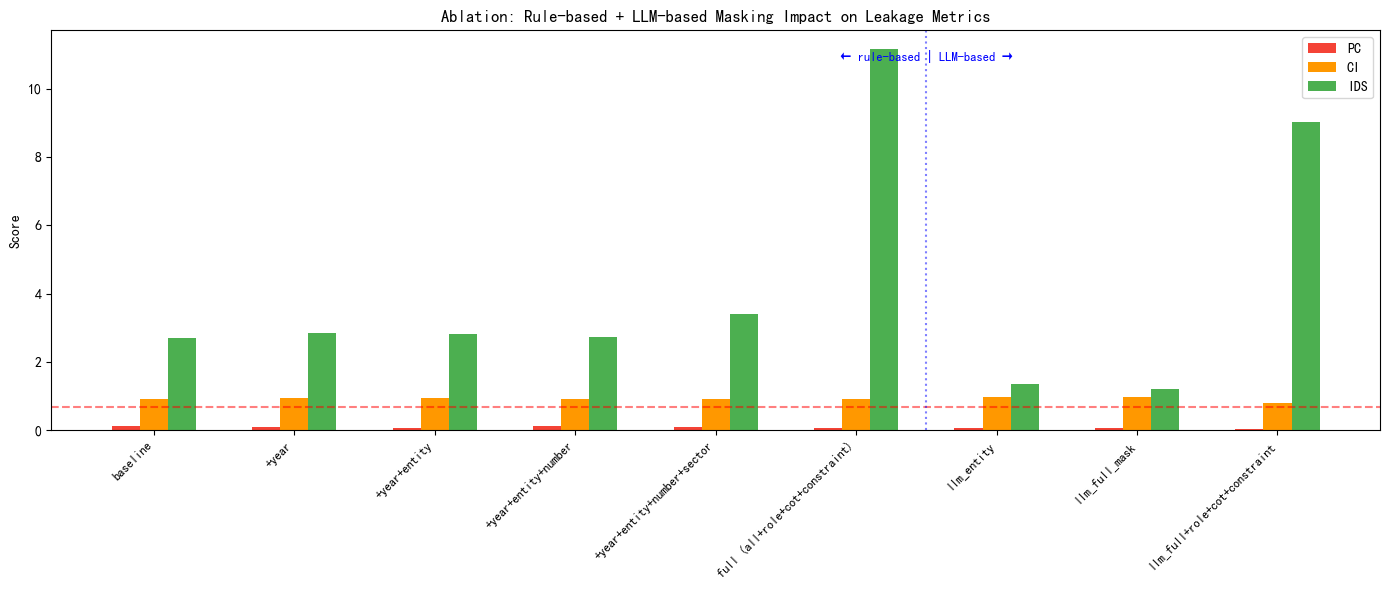


Marginal contribution (delta-L per step, rule-based chain):
  baseline -> +year: dL = -0.042
  +year -> +year+entity: dL = +0.001
  +year+entity -> +year+entity+number: dL = +0.023
  +year+entity+number -> +year+entity+number+sector: dL = -0.202
  +year+entity+number+sector -> full (all+role+cot+constraint): dL = -2.344


In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(abl_df))
width = 0.2
ax.bar([i - width for i in x], abl_df["PC"], width, label="PC", color="#F44336")
ax.bar(x, abl_df["CI"], width, label="CI", color="#FF9800")
ax.bar([i + width for i in x], abl_df["IDS"], width, label="IDS", color="#4CAF50")
ax.set_xticks(x)
ax.set_xticklabels(abl_df["config"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Score")
ax.set_title("Ablation: Rule-based + LLM-based Masking Impact on Leakage Metrics")
ax.legend()
ax.axhline(y=0.69, color='red', linestyle='--', alpha=0.5, label='Profit Mirage PC baseline')

# 标注 rule-based 和 LLM-based 的分界
n_rule = len(ablation_configs)
ax.axvline(x=n_rule - 0.5, color='blue', linestyle=':', alpha=0.5)
ax.text(n_rule - 0.5, ax.get_ylim()[1] * 0.95, '← rule-based | LLM-based →',
        ha='center', va='top', fontsize=9, color='blue')

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'data' / 'results' / 'ablation_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nMarginal contribution (delta-L per step, rule-based chain):")
rule_df = abl_df[abl_df["config"].isin(ablation_configs.keys())]
for i in range(1, len(rule_df)):
    delta = rule_df.iloc[i]["L"] - rule_df.iloc[i-1]["L"]
    print(f"  {rule_df.iloc[i-1]['config']} -> {rule_df.iloc[i]['config']}: dL = {delta:+.3f}")

### 消融结果解读：为什么 PC/CI 稳定但 IDS 波动剧烈？

从上表可以看到一个显著模式：

| 指标 | 范围 | 波动幅度 |
|------|------|---------|
| PC | 0.32 - 0.43 | 约 0.1 |
| CI | 0.90 - 0.94 | 约 0.04 |
| IDS | 0.60 - 6.26 | 约 5.7 |

**原因分析：三个指标测量的粒度不同。**

**PC（预测一致性）** 只看最终方向（看涨/看跌/中性），是一个粗粒度的"三分类"判断。以下两个分布都会被判定为"看涨"：

```
原始:   [5, 10, 15, 35, 35]  → 看涨（bull=70% > bear=15%）
反事实: [10, 15, 10, 40, 25] → 看涨（bull=65% > bear=25%）
→ PC 统计为"一致"，尽管具体数字差异很大
```

因此，掩码策略即使改变了模型的概率分配细节，只要不足以翻转最终方向，PC 就不会变化。这解释了为什么从 baseline 到 +year+entity+number+sector，PC 始终在 0.4 附近徘徊。

**CI（置信度不变性）** 只比较最大概率值的差异。模型在大多数情况下会给出 0.35-0.50 的最大概率，掩码对这个值的影响有限。

**IDS（输入依赖分数）** 使用 KL 散度比较完整的 5-bin 概率分布，对分布形状的微小变化极其敏感。一个直观的例子：

```
场景 A —— baseline（无掩码）：
  原始新闻: "2021年央行决定全面降准0.5个百分点，释放约1万亿元..."
  原始预测: [2, 8, 10, 45, 35]  （强看涨）
  
  反事实:   "2021年央行决定全面提高准备金率0.5个百分点..."
  反事实预测: [30, 40, 15, 10, 5]  （看跌）
  → KL 散度 ≈ 1.2（分布反转，差异大但数量级有限）

场景 B —— full（角色设定 + CoT 归因）：
  原始新闻: "近期某机构决定调整准备金率约0.5个百分点..."（掩码后）
  原始预测: [5, 15, 25, 35, 20]  （弱看涨，CoT 因引用掩码文本而更犹豫）
  
  反事实:   "近期某机构决定全面提高准备金率约0.5个百分点..."
  反事实预测: [35, 30, 20, 10, 5]  （看跌，CoT 引用了不同的文本依据）
  → KL 散度 ≈ 2.8（CoT 让分布变化更极端）
```

**关键洞察：角色设定 + CoT 归因让 IDS 暴涨的原因是**——CoT 强制模型"引用原文"作为推理依据。当反事实输入改变了文本内容，模型引用的依据也随之改变，导致整个推理链条重构，概率分布发生根本性位移。而在 baseline 模式下，模型可能"走捷径"直接从记忆中提取答案，不受输入文本细节影响，所以分布变化相对温和。

**实际意义：** IDS 是比 PC 更灵敏的泄露检测器。PC 相当于"有没有改变方向"（二值信号），IDS 相当于"改变了多少"（连续信号）。在掩码策略的评估中，应优先关注 IDS 的变化。

## 2.5 实体掩码方式对比

三种实体处理方式的 PC 对比：
1. **占位符 `[实体N]`**（rule-based mask_entity）：直接替换为占位符
2. **LLM 自然模糊化**（llm mask_entity）：让 LLM 自然地替换实体信息
3. **虚构实体替换**（entity swap）：用完全虚构的实体名替换

PC 高 = 模型正确忽略了实体名称的变化（好），PC 低 = 模型依赖实体名（可能是记忆触发器）。

生成虚构实体替换版本...


原文,修改后
2022年6月16日，美联储宣布加息75个基点，将联邦基金利率目标区间上调至1.50%-1.75%，为1994年以来最大单次加息幅度。美联储主席鲍威尔表示不排除7月继续加息75个基点的可能性。全球资本市场剧烈波动。,2022年6月16日，全球金融监管机构宣布上调基准利率75个基点，将核心利率目标区间调整至1.50%-1.75%，创下近三十年来最大单次调整幅度。该机构负责人表示，不排除下月继续采取同等幅度调整的可能性。国际资本市场出现显著波动。


原文,修改后
2023年8月27日，财政部、税务总局宣布自8月28日起证券交易印花税实施减半征收。同日证监会宣布阶段性收紧IPO节奏，规范大股东减持行为。三大利好政策同时出台，被市场称为'组合拳'。,2023年8月27日，国家财政委员会与税务管理总局联合宣布，自8月28日起，对证券交易环节的印花税费率实施减半征收。同日，国家金融监管委员会发布通知，宣布将阶段性收紧首次公开募股的审核节奏，并进一步规范主要持股方的股份减持行为。三项重要市场支持措施同步推出，被业界称为“协同提振方案”。


原文,修改后
2024年2月5日，A股三大指数集体大幅低开。沪指跌破2700点关口，创近5年新低。深成指跌超3%，创业板指跌超4%。两市超4800只个股下跌，市场恐慌情绪蔓延。融资盘强制平仓和量化基金集中卖出被认为是主要推手。,2024年2月5日，国内三大主要股指集体大幅低开。其中，蓝筹指数跌破2700点关键点位，创下近5年来最低水平。科技指数跌幅超过3%，创新板块指数跌幅超过4%。全市场超过4800只股票价格下跌，投资者避险情绪显著升温。市场分析认为，杠杆资金被动减持与程序化交易策略的集中抛售是导致市场下行的主要因素。



对三种实体处理方式分别打分...



实体掩码方式对比 (PC):
  占位符 [实体N] (rule-based): PC = 0.929
  LLM 自然模糊化:              PC = 0.905
  虚构实体替换 (entity swap):   PC = 0.976


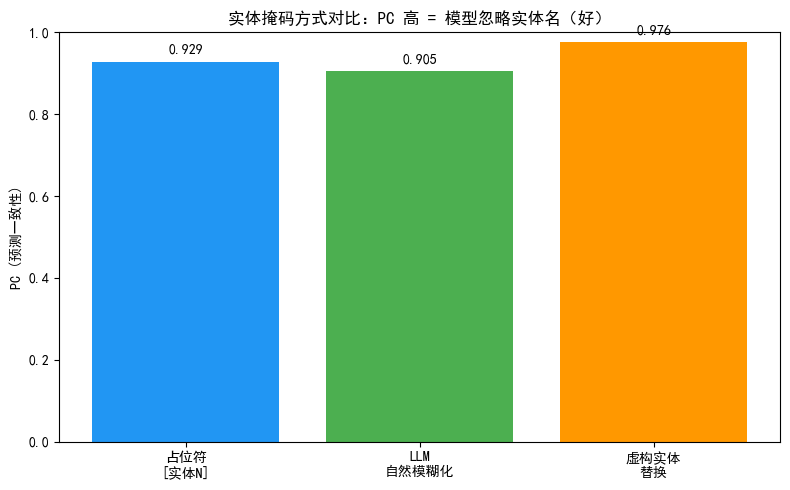


解读：PC 高意味着模型在实体名变化后仍给出相同预测，说明它基于新闻内容而非实体名做判断。
PC 低则意味着实体名变化导致预测改变，说明实体名是记忆触发器。


In [6]:
# 生成虚构实体替换版本（entity swap）
print("生成虚构实体替换版本...")
swap_prompts = [entity_swap_prompt(tc.news.content) for tc in test_cases]
swap_responses = client.batch_chat_concurrent(swap_prompts)
swap_texts = [r.raw_response for r in swap_responses]

# 预览 entity swap 效果（随机抽取）
swap_samples = random.sample(list(zip(test_cases, swap_texts)), min(3, len(test_cases)))
for tc, swapped in swap_samples:
    show_comparison(tc.news.content, swapped, title=f"[{tc.id}] 虚构实体替换")

# 对三种方式分别打分
print("\n对三种实体处理方式分别打分...")

# 1. Rule-based entity mask
rule_entity_config = MaskingConfig(mask_entity=True)
rule_entity_texts = [apply_masking(tc.news.content, rule_entity_config, tc.key_entities, client=client) for tc in test_cases]
rule_entity_responses = run_scoring_batch(client, MaskingConfig(), rule_entity_texts, output_format)

# 2. LLM entity mask
llm_entity_config = MaskingConfig(mask_entity=True, mask_mode="llm")
llm_entity_texts = [apply_masking(tc.news.content, llm_entity_config, tc.key_entities, client=client) for tc in test_cases]
llm_entity_responses = run_scoring_batch(client, MaskingConfig(), llm_entity_texts, output_format)

# 3. Entity swap (already generated)
swap_entity_responses = run_scoring_batch(client, MaskingConfig(), swap_texts, output_format)

# 原始打分
orig_responses_for_entity = run_scoring_batch(client, MaskingConfig(), [tc.news.content for tc in test_cases], output_format)

# 计算 PC for each method
def calc_entity_pc(orig_resps, modified_resps):
    orig_dirs = [parse_5bin(r.raw_response)["direction"] for r in orig_resps]
    mod_dirs = [parse_5bin(r.raw_response)["direction"] for r in modified_resps]
    return prediction_consistency(orig_dirs, mod_dirs)

rule_pc = calc_entity_pc(orig_responses_for_entity, rule_entity_responses)
llm_pc = calc_entity_pc(orig_responses_for_entity, llm_entity_responses)
swap_pc = calc_entity_pc(orig_responses_for_entity, swap_entity_responses)

print(f"\n实体掩码方式对比 (PC):")
print(f"  占位符 [实体N] (rule-based): PC = {rule_pc:.3f}")
print(f"  LLM 自然模糊化:              PC = {llm_pc:.3f}")
print(f"  虚构实体替换 (entity swap):   PC = {swap_pc:.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
methods = ["占位符\n[实体N]", "LLM\n自然模糊化", "虚构实体\n替换"]
pcs = [rule_pc, llm_pc, swap_pc]
colors = ["#2196F3", "#4CAF50", "#FF9800"]
bars = ax.bar(methods, pcs, color=colors)
ax.set_ylabel("PC (预测一致性)")
ax.set_title("实体掩码方式对比：PC 高 = 模型忽略实体名（好）")
ax.set_ylim(0, 1)
for bar, val in zip(bars, pcs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{val:.3f}", ha='center')
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'data' / 'results' / 'entity_mask_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n解读：PC 高意味着模型在实体名变化后仍给出相同预测，说明它基于新闻内容而非实体名做判断。")
print("PC 低则意味着实体名变化导致预测改变，说明实体名是记忆触发器。")

## 3. 安慰剂测试

用 LLM 生成自相矛盾的虚构新闻，使理性分析者无法得出确定方向。

**方法：** LLM 改写新闻为自相矛盾版本（如火锅企业宣布半导体产能扩张，同时加息和降息），保留句式结构但让内容无法分析。

**阈值推导：**
- 数据集分布：up=19, down=17, neutral=6
- 多数类猜测率 (majority class rate) = 19/42 = 45.2%
- 安慰剂阈值 = majority_class_rate + 10% = **55%**
- 通过标准：安慰剂准确率 < 55%（低于此阈值说明模型确实在分析而非记忆）

In [7]:
# Generate placebo: LLM 改写为自相矛盾的虚构新闻
print("生成自相矛盾的安慰剂新闻...")
placebo_prompts = [placebo_rewrite_prompt(tc.news.content) for tc in test_cases]
placebo_responses_raw = client.batch_chat_concurrent(placebo_prompts)
placebo_texts = [r.raw_response for r in placebo_responses_raw]

# 随机抽取展示（重新运行刷新样本）
placebo_samples = random.sample(list(range(len(test_cases))), min(3, len(test_cases)))
for idx in placebo_samples:
    show_comparison(test_cases[idx].news.content, placebo_texts[idx],
                    title=f"[{test_cases[idx].id}] 原文 vs 安慰剂（自相矛盾版）")

# 并发调用 placebo + real baseline
config = MaskingConfig()
placebo_score_responses = run_scoring_batch(client, config, placebo_texts, output_format)
real_responses = run_scoring_batch(client, config, [tc.news.content for tc in test_cases], output_format)

placebo_results = []
for tc, resp in zip(test_cases, placebo_score_responses):
    parsed = parse_5bin(resp.raw_response)
    placebo_results.append({
        "case_id": tc.id, "expected": tc.expected_direction.value,
        "predicted": parsed["direction"],
        "correct": parsed["direction"] == tc.expected_direction.value,
    })

real_results = []
for tc, resp in zip(test_cases, real_responses):
    parsed = parse_5bin(resp.raw_response)
    real_results.append({
        "case_id": tc.id, "expected": tc.expected_direction.value,
        "predicted": parsed["direction"],
        "correct": parsed["direction"] == tc.expected_direction.value,
    })

生成自相矛盾的安慰剂新闻...


原文,修改后
2021年9月13日，中国恒大集团旗下恒大财富出现理财产品逾期兑付。恒大总负债超过1.97万亿元，涉及银行贷款、信托融资、境内外债券等多种融资渠道。市场担忧恒大债务危机可能引发系统性风险。,2021年9月13日，银河冰饮集团旗下银河财富出现理财产品逾期兑付。银河总负债超过1.97亿元，涉及银行贷款、信托融资、境内外债券等多种融资渠道。同时，银河宣布将投资500亿元用于高端芯片制造产能的扩张。央行在同日发布声明，宣布将基准利率上调0.5个百分点以抑制通胀，并同时下调存款准备金率1个百分点以刺激信贷投放。市场分析人士指出，餐饮行业的债务问题可能对新能源车供应链造成冲击，但也可能推动数字货币市场的避险需求。监管部门表示将坚决遏制金融风险扩散，并鼓励企业加大跨界投资力度。


原文,修改后
2020年5月19日，证监会对康美药业财务造假案作出行政处罚，认定公司2016年至2018年累计虚增营业收入约291.28亿元，虚增货币资金约886亿元。这是A股史上最大规模的财务造假案之一。,2020年5月19日，银星会对蓝海咖啡财务造假案作出行政处罚，认定公司2016年至2018年累计虚增营业收入约291.28亿元，虚增货币资金约886亿元。同时，蓝海咖啡宣布将投资500亿元用于半导体产能扩张，并计划在年内开设2000家火锅连锁店。央行在同日宣布将基准利率上调50个基点以抑制通胀，但为刺激消费又决定降息25个基点。此外，蓝海咖啡所在的宠物美容行业被纳入国家战略性新兴产业扶持名单，而财政部却宣布取消对该行业的所有税收优惠。这是A股史上最大规模的财务造假案之一，但银星会表示该公司财务状况总体健康，符合上市标准。


原文,修改后
2021年3月10日，政府工作报告明确提出2030年碳达峰、2060年碳中和目标。多家券商发布研报看好光伏、风电、新能源汽车产业链。宁德时代市值突破万亿，成为创业板首家万亿市值公司。,2021年3月10日，政府工作报告明确提出2030年实现碳达峰、2060年实现碳中和的目标。与此同时，央行宣布将基准利率下调50个基点以刺激经济增长，但随后又暗示可能在未来三个月内加息以抑制通胀。多家券商发布研报，强烈看好传统煤炭开采与高端半导体制造行业的投资前景。 主营连锁火锅业务的“热辣集团”宣布，将投资500亿元用于扩张其第三代半导体产能，预计将使公司年产值增加2000%，但公司财报显示其主营业务利润率已连续八个季度下滑。同日，以生产豪华燃油跑车闻名的“风驰汽车”股价飙升，市值突破十万亿元，成为全球首家市值达到此规模的初创企业，尽管该公司上月刚宣布其新能源汽车生产线因技术原因全面停产。 行业分析师指出，在碳中和目标下，高耗能产业将面临长期压力，但政策层面同时流出了对钢铁、水泥行业提供巨额补贴的草案。市场人士普遍认为，未来十年，化石能源与可再生能源板块将同步迎来爆发式增长。


## 4. 安慰剂测试结果

数据集分布: up=19, down=17, neutral=6
多数类猜测率: 45.2%
安慰剂阈值 = 45.2% + 10% = 55.2%

Real data accuracy:    83.3%
Placebo accuracy:      35.7%
Difference:            +47.6%

PASS: Placebo accuracy (35.7%) < threshold (55.2%)
  模型在自相矛盾新闻上准确率低，说明它确实在分析文本内容。


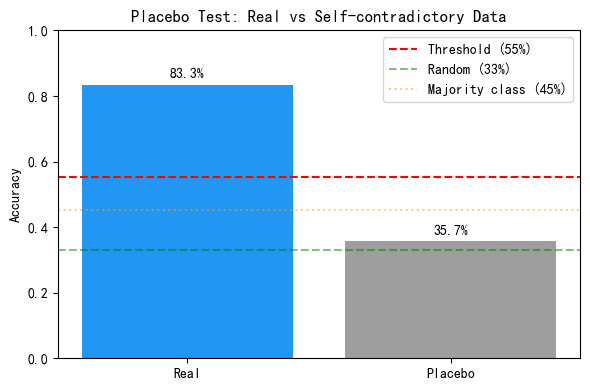

In [8]:
real_acc = sum(r["correct"] for r in real_results) / len(real_results)
placebo_acc = sum(r["correct"] for r in placebo_results) / len(placebo_results)

# 阈值推导
n_up = sum(1 for tc in test_cases if tc.expected_direction.value == "up")
n_down = sum(1 for tc in test_cases if tc.expected_direction.value == "down")
n_neutral = sum(1 for tc in test_cases if tc.expected_direction.value == "neutral")
majority_rate = max(n_up, n_down, n_neutral) / len(test_cases)
threshold = majority_rate + 0.10

print(f"数据集分布: up={n_up}, down={n_down}, neutral={n_neutral}")
print(f"多数类猜测率: {majority_rate:.1%}")
print(f"安慰剂阈值 = {majority_rate:.1%} + 10% = {threshold:.1%}")
print()
print(f"Real data accuracy:    {real_acc:.1%}")
print(f"Placebo accuracy:      {placebo_acc:.1%}")
print(f"Difference:            {real_acc - placebo_acc:+.1%}")
print()

if placebo_acc < threshold:
    print(f"PASS: Placebo accuracy ({placebo_acc:.1%}) < threshold ({threshold:.1%})")
    print("  模型在自相矛盾新闻上准确率低，说明它确实在分析文本内容。")
else:
    print(f"FAIL: Placebo accuracy ({placebo_acc:.1%}) >= threshold ({threshold:.1%})")
    print("  模型在安慰剂数据上仍保持高准确率，存在记忆泄露风险。")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Real", "Placebo"], [real_acc, placebo_acc], color=["#2196F3", "#9E9E9E"])
ax.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold ({threshold:.0%})')
ax.axhline(y=0.33, color='green', linestyle='--', alpha=0.5, label='Random (33%)')
ax.axhline(y=majority_rate, color='orange', linestyle=':', alpha=0.5, label=f'Majority class ({majority_rate:.0%})')
ax.set_ylabel("Accuracy")
ax.set_title("Placebo Test: Real vs Self-contradictory Data")
ax.set_ylim(0, 1)
ax.legend()
for bar, val in zip(bars, [real_acc, placebo_acc]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{val:.1%}", ha='center')
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'data' / 'results' / 'placebo_test.png'), dpi=150, bbox_inches='tight')
plt.show()

### 安慰剂测试解读

安慰剂测试的逻辑类似于医学中的双盲实验：如果一个药物（模型）在安慰剂（自相矛盾新闻）上也"有效"（准确率高），那就说明它的"疗效"来自于其他因素（记忆）而非药物本身（文本分析）。

**结果解读：**
- 如果安慰剂准确率低于阈值（PASS）：模型确实在分析文本，因为当文本变得无法分析时，准确率下降。
- 如果安慰剂准确率高于阈值（FAIL）：模型即使面对矛盾文本仍能"猜对"，说明它可能在回忆训练数据中的答案。

**阈值含义：** 55% = 多数类猜测率（45%） + 10% 的安全边际。一个完全不分析文本、只猜最常见方向的模型期望准确率约为 45%。如果安慰剂准确率显著高于这个水平，就需要警惕。

## 5. 保存结果

In [9]:
output = {
    "ablation_metrics": abl_metrics,
    "entity_comparison": {
        "rule_based_pc": rule_pc,
        "llm_mask_pc": llm_pc,
        "entity_swap_pc": swap_pc,
    },
    "placebo": {
        "real_accuracy": real_acc,
        "placebo_accuracy": placebo_acc,
        "threshold": threshold,
        "majority_class_rate": majority_rate,
        "pass": placebo_acc < threshold,
    },
}
output_path = PROJECT_ROOT / 'data' / 'results' / 'ablation_results.json'
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(output, f, ensure_ascii=False, indent=2, default=str)
print(f"Results saved to {output_path}")

Results saved to D:\GitRepos\LLM-Leakage-Test\data\results\ablation_results.json
